# Multiple Linear Regression

## Adding the effects of two inputs

A simple score model adds a starting score, a study-time term, and a sleep-time term. With invented round-number coefficients, the calculation is:

$$\text{predicted score}=25+5\times\text{study hours}+2\times\text{sleep hours}.$$

For 4 hours of study and 7 hours of sleep:

$$25+5\times4+2\times7=25+20+14=59.$$

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/03_adding_two_inputs.png" alt="A starting score of 25 plus 20 study points and 14 sleep points gives a prediction of 59." width="640" style="max-width:100%;height:auto;">

Holding sleep time fixed, an extra study hour changes this model's prediction by 5 points. Holding study time fixed, an extra sleep hour changes it by 2 points. These are relationships in an invented dataset, not evidence that changing a student's habits causes those score changes.

The fitted example estimates its coefficients from noisy data, so its numbers differ slightly from 25, 5, and 2. The graph shows study time against score. Gray dots are training observations; blue dots have sleep times close to the selected value. The line uses exactly the selected sleep time, and the orange dot uses both selected inputs.

## Fitting one rule to many measurements

Let $b$ be the starting score, $a$ the study coefficient, and $c$ the sleep coefficient. If one record has 4 study hours, 7 sleep hours, and a score of 60, its error is $60-(b+4a+7c)$. OLS adds the squared errors from every record and chooses the coefficients with the smallest total.

The program stores one record per row in a design matrix and solves these calculations together. The fitting cost is convex: a local minimum is also a global minimum. A unique set of coefficients requires inputs that do not exactly repeat information already supplied by the other inputs.

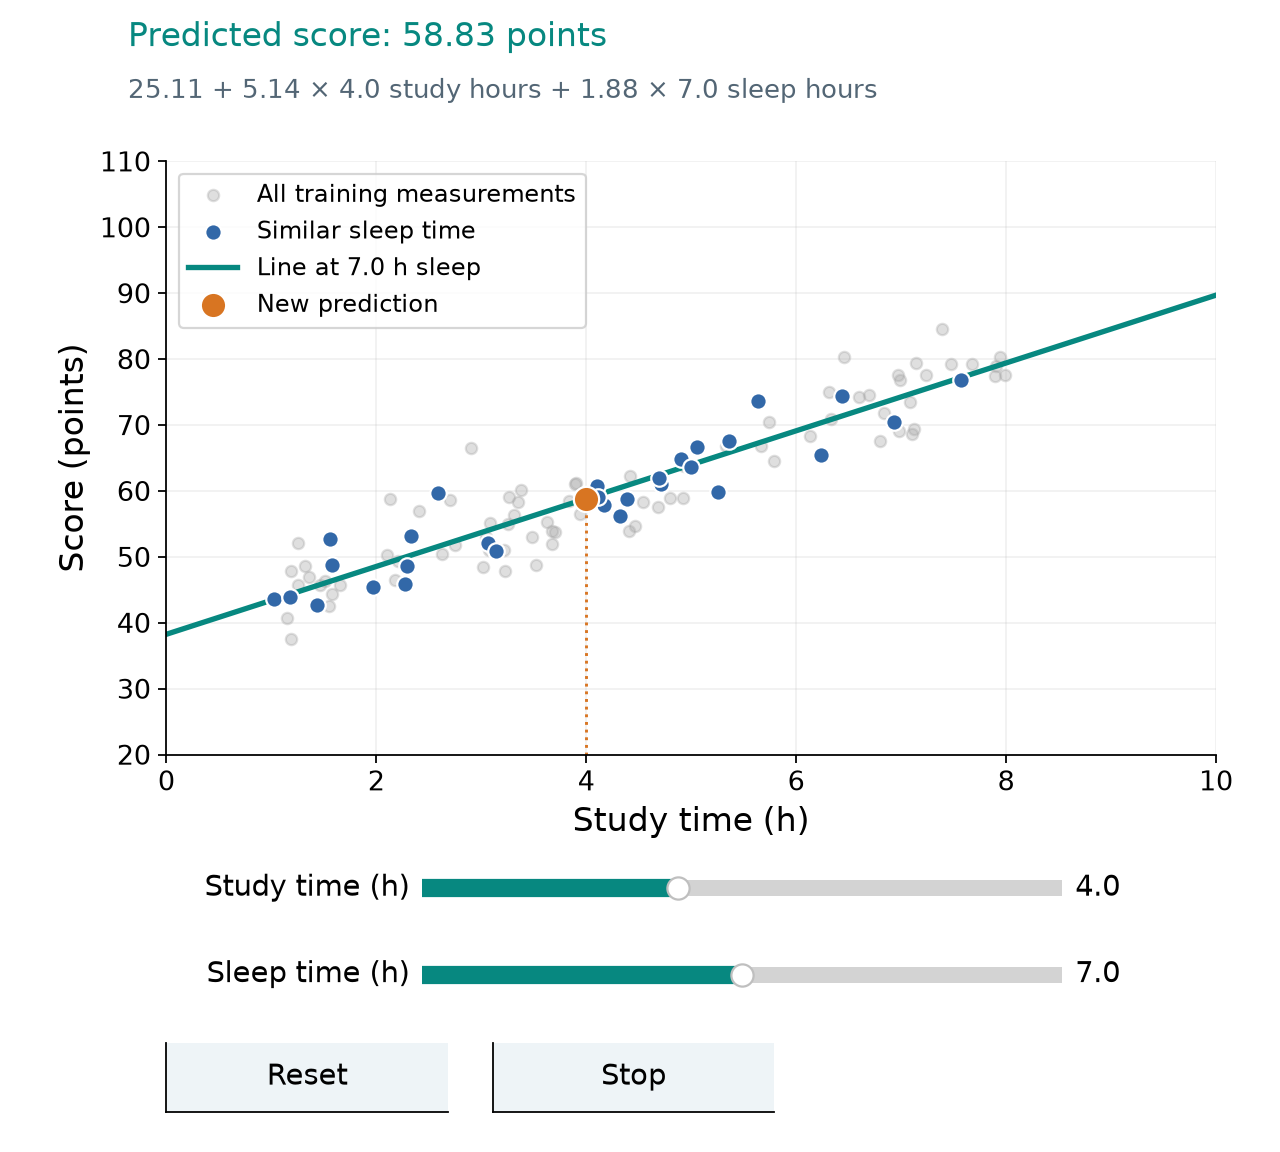

In [1]:
import os
import sys
import io
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display


# Bundle the required DejaVu Sans characters for offline browser rendering.
_regression_font = Path(gettempdir()) / "regression-lecture-font.ttf"
_regression_font_data = base64.b64decode("...")
if not _regression_font.exists() or _regression_font.read_bytes() != _regression_font_data:
    _regression_font.write_bytes(_regression_font_data)
font_manager.fontManager.addfont(str(_regression_font))
plt.rcParams.update({
    "font.family": font_manager.FontProperties(fname=str(_regression_font)).get_name(),
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    plt.pause(.04)
            finally:
                self.stop()
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show()

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)


rng_score = np.random.default_rng(63)
study_hours = rng_score.uniform(1, 8, 160)
sleep_hours = rng_score.uniform(5, 9, 160)
# An invented local relationship, not a claim about real student performance.
score = 25 + 5 * study_hours + 2 * sleep_hours + rng_score.normal(0, 3, 160)
features = np.column_stack([study_hours, sleep_hours])
order = rng_score.permutation(len(score))
score_train, score_test = order[:110], order[110:]
X_train = np.column_stack([np.ones(len(score_train)), features[score_train]])
X_test = np.column_stack([np.ones(len(score_test)), features[score_test]])
beta, _, design_rank, _ = np.linalg.lstsq(X_train, score[score_train], rcond=None)
score_prediction = X_test @ beta


score_test_metrics = metrics(score[score_test], score_prediction)
study_line = np.linspace(0, 10, 100)


def render_score_query(view, study, sleep):
    query = np.array([1., study, sleep])
    prediction = float(query @ beta)
    lower, upper = features[score_train].min(axis=0), features[score_train].max(axis=0)
    within = bool(np.all(([study, sleep] >= lower) & ([study, sleep] <= upper)))
    distance = np.linalg.norm((features[score_train] - [study, sleep]) / (upper - lower), axis=1).min()
    nearby = np.abs(sleep_hours[score_train]-sleep) <= .35
    line_prediction = beta[0] + beta[1]*study_line + beta[2]*sleep
    ax = view.ax
    ax.scatter(study_hours[score_train], score[score_train], color="0.65", s=26,
               alpha=.35, label="All training measurements")
    ax.scatter(study_hours[score_train][nearby], score[score_train][nearby], color=BLUE,
               edgecolor="white", s=55, zorder=4, label="Similar sleep time")
    ax.plot(study_line, line_prediction, color=TEAL, label=f"Line at {sleep:.1f} h sleep")
    ax.scatter([study], [prediction], color=ORANGE, edgecolor="white", s=130, zorder=6,
               label="New prediction")
    ax.vlines(study, 20, prediction, color=ORANGE, linestyle=":", linewidth=1.3)
    ax.set(xlabel="Study time (h)", ylabel="Score (points)", xlim=(0, 10), ylim=(20, 110))
    ax.legend(loc="upper left")
    if not within:
        ax.text(.98, .03, "Outside the observed input ranges", transform=ax.transAxes,
                ha="right", fontsize=11, color=ORANGE)
    view.status.set_text(f"Predicted score: {prediction:.2f} points")
    view.detail.set_text(f"{beta[0]:.2f} + {beta[1]:.2f} × {study:.1f} study hours + {beta[2]:.2f} × {sleep:.1f} sleep hours")
    return {"query": query, "prediction": prediction, "within_marginal_ranges": within,
            "nearest_scaled_distance": distance, "metrics": score_test_metrics,
            "nearby": nearby, "line_prediction": line_prediction}


score_query_demo = RegressionExplorer("score_query", render_score_query, [
    ("study", "Study time (h)", 0, 10, 4, .1, "%0.1f"),
    ("sleep", "Sleep time (h)", 3, 11, 7, .1, "%0.1f"),
])
score_query_demo.start()

## Recording the same study time twice

Four hours and 240 minutes describe the same amount of study. Adding both as separate inputs does not supply new information. For example, these two calculations give the same study contribution:

$$5\times4=20,$$
$$2\times4+0.05\times240=8+12=20.$$

The coefficients differ, but the predictions agree. The equality also holds for any other study time because minutes always equal 60 times hours. This is an exact case of multicollinearity, where inputs repeat information.

The control adds a chosen amount to the hours coefficient and subtracts that amount divided by 60 from the minutes coefficient. The blue and orange predicted points remain on top of each other. Inputs that almost repeat information can also make coefficients sensitive to small measurement changes.

A large correlation between two inputs is a warning rather than an automatic deletion rule. Dependence can also involve several inputs together. Uncertain coefficients, or a large p-value in a statistical test, do not prove that an input has no effect.

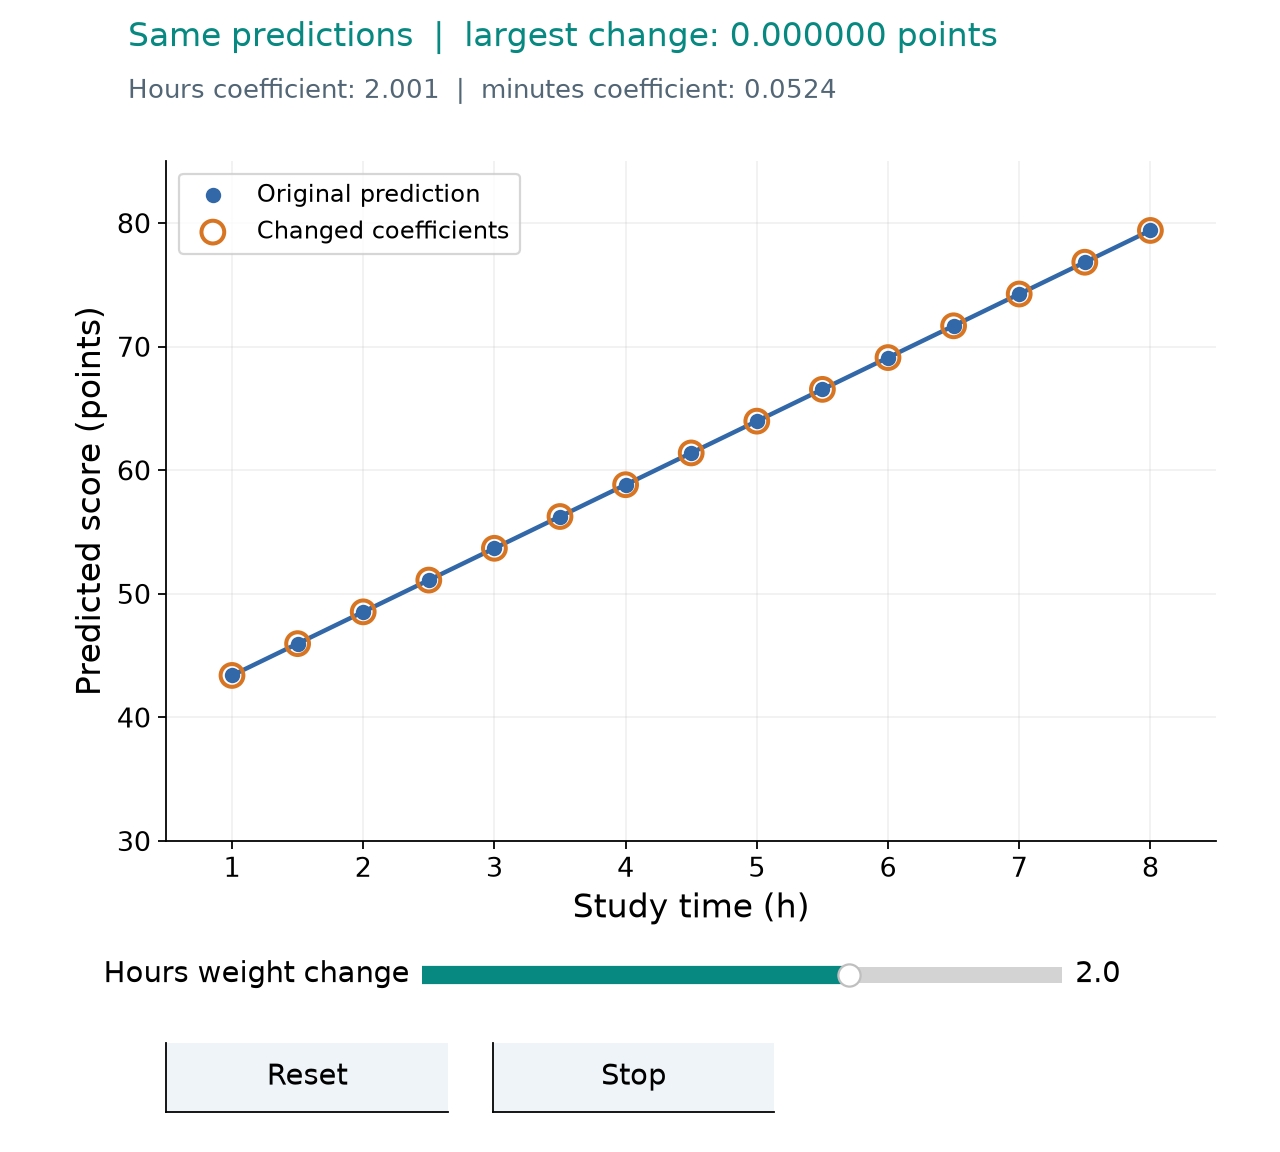

In [2]:
# Add an exact duplicate in a different unit.
X_redundant = np.column_stack([X_train, 60 * study_hours[score_train]])
beta_redundant, _, redundant_rank, _ = np.linalg.lstsq(
    X_redundant, score[score_train], rcond=None)

# Adding 60 to the hours coefficient and subtracting 1 from the minutes
# coefficient changes no prediction when minutes = 60 * hours.
null_direction = np.array([0.0, 60.0, 0.0, -1.0])
beta_alternative = beta_redundant + null_direction
prediction_difference = X_redundant @ beta_alternative - X_redundant @ beta_redundant


def render_redundancy(view, shift):
    # Add shift to the hours coefficient and subtract shift/60 from minutes.
    alternative = beta_redundant + (shift/60) * null_direction
    reference = X_redundant @ beta_redundant
    prediction = X_redundant @ alternative
    difference = float(np.max(np.abs(prediction - reference)))
    hours = np.linspace(1, 8, 15)
    inputs = np.column_stack([np.ones(len(hours)), hours, np.full(len(hours), 7), 60*hours])
    original_line = inputs @ beta_redundant
    changed_line = inputs @ alternative
    ax = view.ax
    ax.plot(hours, original_line, color=BLUE, linewidth=2)
    ax.scatter(hours, original_line, color=BLUE, s=35, zorder=4, label="Original prediction")
    ax.scatter(hours, changed_line, facecolors="none", edgecolors=ORANGE, s=105,
               linewidths=1.8, zorder=5, label="Changed coefficients")
    ax.set(xlabel="Study time (h)", ylabel="Predicted score (points)", xlim=(.5, 8.5), ylim=(30, 85))
    ax.legend(loc="upper left")
    view.status.set_text(f"Same predictions  |  largest change: {difference:.6f} points")
    view.detail.set_text(f"Hours coefficient: {alternative[1]:.3f}  |  minutes coefficient: {alternative[3]:.4f}")
    return {"coefficients": alternative, "prediction": prediction, "reference": reference,
            "difference": difference, "original_line": original_line, "changed_line": changed_line}


redundancy_demo = RegressionExplorer("redundancy", render_redundancy, [
    ("shift", "Hours weight change", -6, 6, 2, .1, "%0.1f"),
])
redundancy_demo.start()

Two familiar input values can still form an unfamiliar pair. A dataset may contain short study times with long sleep times and long study times with short sleep times, but few examples of both being long. Predictions need support from similar combinations, not just each input's separate range.